# 🎮 Entrenamiento de un Agente DQN para Super Mario Bros con TF-Agents

Este notebook implementa un agente de Aprendizaje por Refuerzo (RL) usando la arquitectura **Deep Q-Network (DQN)** entrenado en el entorno `SuperMarioBros` mediante la librería `TF-Agents`.



## 🔧 1. Instalación Limpia y Compatible para Entrenamiento con TF-Agents y Gym

Este bloque se encarga de desinstalar versiones en conflicto de TensorFlow, TF-Agents y otras dependencias, para luego instalar versiones **específicas y compatibles** necesarias para entrenar agentes de aprendizaje por refuerzo (Reinforcement Learning).

Se incluyen bibliotecas clave como:

- `tensorflow==2.13.0` y `tensorflow-probability==0.21.0`: para garantizar compatibilidad con TF-Agents.
- `tf-agents==0.17.0`: librería principal para construcción de agentes RL.
- `gym[atari,box2d,accept-rom-license]` y `gym-super-mario-bros`: entornos de simulación clásicos y de videojuegos.
- `imageio`, `pyvirtualdisplay`, `pyglet`, `swig`: necesarias para renderizado y grabación de episodios.

> ⚠️ Este paso es **esencial** para evitar errores durante la ejecución de notebooks en Kaggle relacionados con incompatibilidades entre versiones.


In [1]:
# Desinstalar posibles conflictos
!pip uninstall -y tensorflow tensorflow-probability tf-agents tf-agents-nightly

# Instalar versiones compatibles
!pip install tensorflow==2.13.0
!pip install tensorflow-probability==0.21.0
!pip install tf-agents==0.17.0
!pip install 'imageio==2.4.0'
!pip install pyvirtualdisplay pyglet swig
!pip install gym[atari,box2d,accept-rom-license]
!pip install gym-super-mario-bros


Found existing installation: tensorflow 2.18.0
Uninstalling tensorflow-2.18.0:
  Successfully uninstalled tensorflow-2.18.0
Found existing installation: tensorflow-probability 0.25.0
Uninstalling tensorflow-probability-0.25.0:
  Successfully uninstalled tensorflow-probability-0.25.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 524.2/524.2 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 98.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.8/440.8 kB 32.0 MB/s eta 0:00:00
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.14.0
    Uninstalling typing_extensions-4.14.0:
      Successfully uninstalled typing_extensions-4.14.0
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successful

## 🕹️ 2. Inicialización del Entorno y Librerías para Entrenamiento en Super Mario Bros

Este bloque importa todas las librerías necesarias para trabajar con aprendizaje por refuerzo en el entorno `SuperMarioBros`, integrando `TF-Agents`, `Gym` y `gym-super-mario-bros`.

Incluye los siguientes pasos clave:

- **Importación de librerías**:
  - `gym`, `gym_super_mario_bros`, `nes_py`, `tf_agents`: para definir, envolver y entrenar entornos de aprendizaje por refuerzo.
  - `IPython.display`, `imageio`, `pyvirtualdisplay`: para renderizar y mostrar videos en el entorno de Kaggle.
  - `tensorflow`, `numpy`, `os`: librerías base para cómputo y manejo del sistema.

- **Definición de acciones**:
  - Se usa `SIMPLE_MOVEMENT` para restringir el espacio de acciones de Mario, facilitando el entrenamiento.

- **Wrappers de entorno**:
  - Se aplican transformaciones al entorno (`GrayScaleObservation`, `ResizeObservation`, `FrameStack`) para simplificar la entrada visual a la red neuronal.

- **Renderizado en entornos sin GUI**:
  - Se inicia un `Display` virtual para permitir la visualización de episodios y grabación de videos directamente en notebooks.

> ✅ Este paso es fundamental para preparar el entorno y las herramientas necesarias para implementar y entrenar un agente DQN en Super Mario Bros.


In [2]:
import os
import numpy as np
import tensorflow as tf
import gym
import gym_super_mario_bros
from gym_super_mario_bros.actions import SIMPLE_MOVEMENT
from nes_py.wrappers import JoypadSpace
from gym.wrappers import GrayScaleObservation, ResizeObservation, FrameStack
from IPython.display import HTML
from base64 import b64encode
import imageio
from pyvirtualdisplay import Display

from tf_agents.environments import gym_wrapper, tf_py_environment
from tf_agents.networks.q_network import QNetwork
from tf_agents.agents.dqn.dqn_agent import DqnAgent
from tf_agents.utils import common
from tf_agents.policies import random_tf_policy
from tf_agents.replay_buffers import tf_uniform_replay_buffer
from tf_agents.trajectories import trajectory
from tf_agents.policies import policy_saver

# Iniciar display virtual para renderizado en video
display = Display(visible=0, size=(1400, 900))
display.start()

/usr/local/lib/python3.11/dist-packages/gymnasium/envs/registration.py:596: UserWarning: WARN: plugin: shimmy.registration:register_gymnasium_envs raised Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/gymnasium/envs/registration.py", line 594, in load_plugin_envs
    fn()
  File "/usr/local/lib/python3.11/dist-packages/shimmy/registration.py", line 304, in register_gymnasium_envs
    _register_atari_envs()
  File "/usr/local/lib/python3.11/dist-packages/shimmy/registration.py", line 244, in _register_atari_envs
    _register_atari_configs(
  File "/usr/local/lib/python3.11/dist-packages/shimmy/registration.py", line 168, in _register_atari_configs
    from ale_py.roms import utils as rom_utils
ImportError: cannot import name 'utils' from 'ale_py.roms' (/usr/local/lib/python3.11/dist-packages/ale_py/roms/__init__.py)

  logger.warn(f"plugin: {plugin.value} raised {traceback.format_exc()}")


## 🏆 3. Recompensa Personalizada para Super Mario Bros

Este bloque define una clase `CustomRewardMario`, que extiende el entorno original de `gym_super_mario_bros` para modificar la función de recompensa y mejorar el comportamiento del agente durante el entrenamiento.

### Características principales:

- **Hereda de `gym.Wrapper`**: permite envolver el entorno sin modificar su implementación original.
- **Penalización por retroceso**:
  - Si Mario retrocede más de 5 unidades en el eje *x*, se aplica una penalización de `-10`.
- **Penalización por estancamiento**:
  - Si Mario no avanza en el eje *x* por 15 pasos consecutivos, se asume que está estancado y se penaliza también con `-10`.

### Variables internas:
- `self.prev_x`: almacena la posición anterior de Mario en el eje horizontal.
- `self.stuck_counter`: cuenta cuántos pasos lleva Mario sin avanzar.

> 🧠 Esta recompensa personalizada incentiva al agente a avanzar constantemente y evitar retroceder o quedarse atrapado, lo cual puede mejorar significativamente el desempeño y velocidad de aprendizaje del modelo.


In [3]:
class CustomRewardMario(gym.Wrapper):
    def __init__(self, env):
        super(CustomRewardMario, self).__init__(env)
        self.prev_x = 0
        self.stuck_counter = 0

    def reset(self, **kwargs):
        self.prev_x = 0
        self.stuck_counter = 0
        return self.env.reset(**kwargs)

    def step(self, action):
        obs, reward, done, info = self.env.step(action)
        x_pos = info.get("x_pos", 0)

        # Penalizar retroceso significativo
        if x_pos < self.prev_x - 5:
            reward -= 10

        # Penalizar estancamiento si no avanza
        if abs(x_pos - self.prev_x) < 1:
            self.stuck_counter += 1
            if self.stuck_counter >= 15:
                reward -= 10
        else:
            self.stuck_counter = 0

        self.prev_x = x_pos
        return obs, reward, done, info


## 🏗️ 4. Creación y Preprocesamiento del Entorno de Mario

Este bloque define la función `create_mario_env`, que construye y preprocesa el entorno de Super Mario Bros para entrenamiento con TF-Agents. Se configura tanto el entorno de **entrenamiento** como el de **evaluación**.

### 🔁 Flujo de construcción del entorno:

1. **Cargar entorno base**:
   - Se instancia una versión específica del entorno `SuperMarioBros-v1`.

2. **Restringir espacio de acciones**:
   - Se aplica `JoypadSpace` con `SIMPLE_MOVEMENT` para limitar las acciones a un conjunto reducido.

3. **Aplicar Wrapper de recompensa personalizada**:
   - Se utiliza `CustomRewardMario` para incentivar el avance y evitar el estancamiento o retroceso.

4. **Preprocesamiento visual**:
   - `GrayScaleObservation`: convierte la imagen a escala de grises.
   - `ResizeObservation`: redimensiona la imagen a 84×84 píxeles.
   - `FrameStack`: apila las últimas 4 observaciones para capturar el movimiento temporal.

5. **Conversión a TF-Agents**:
   - `gym_wrapper.GymWrapper`: convierte el entorno de Gym al formato compatible con TF-Agents.
   - `TFPyEnvironment`: adapta el entorno a un entorno en TensorFlow para entrenamiento.

### ⚙️ Resultado:

- `train_env`: entorno listo para entrenar el agente.
- `eval_env`: entorno separado usado exclusivamente para evaluación del desempeño.

> 🎮 Este paso asegura que el entorno esté correctamente preprocesado y adaptado para ser utilizado con agentes DQN de TF-Agents.


In [4]:
def create_mario_env(version="v1"):
    env = gym_super_mario_bros.make(f"SuperMarioBros-{version}")
    env = JoypadSpace(env, SIMPLE_MOVEMENT)
    env = CustomRewardMario(env)  # Wrapper que ajusta recompensas
    env = GrayScaleObservation(env, keep_dim=True)
    env = ResizeObservation(env, 84)
    env = FrameStack(env, 4)
    return gym_wrapper.GymWrapper(env)

train_py_env = create_mario_env("v1")
eval_py_env = create_mario_env("v1")
train_env = tf_py_environment.TFPyEnvironment(train_py_env)
eval_env = tf_py_environment.TFPyEnvironment(eval_py_env)


/usr/local/lib/python3.11/dist-packages/gym/envs/registration.py:505: UserWarning: WARN: The environment SuperMarioBros-v1 is out of date. You should consider upgrading to version `v3` with the environment ID `SuperMarioBros-v3`.
  logger.warn(


## 🧠 5. Definición del Agente DQN y Red Q

Este bloque configura la red neuronal `QNetwork` y construye el agente `DqnAgent` utilizando la API de TF-Agents, adecuado para tareas de control en entornos visuales como Super Mario Bros.

### 🧩 Arquitectura de la Red Q (`QNetwork`)

- **Preprocesamiento**:
  - Se usa una capa `Lambda` para normalizar las observaciones visuales, escalando los píxeles de `0–255` a `0–1`.

- **Capas Convolucionales** (`conv_layer_params`):
  - `(32, (8, 8), 4)`: 32 filtros, kernel 8×8, stride 4.
  - `(64, (4, 4), 2)`: 64 filtros, kernel 4×4, stride 2.
  - `(64, (3, 3), 1)`: 64 filtros, kernel 3×3, stride 1.

- **Capas Densas** (`fc_layer_params`):
  - Una capa totalmente conectada con 512 unidades antes de la capa de salida.

### 🤖 Configuración del Agente DQN (`DqnAgent`)

- **Especificaciones**:
  - Se utilizan los espacios de observación y acción definidos por el entorno.
  - Se aplica una política ε-greedy con `ε = 0.1` para exploración.

- **Parámetros del entrenamiento**:
  - Optimización con `RMSprop` (tasa de aprendizaje = 2.5e-4, ρ = 0.95, ε = 0.01).
  - Función de pérdida: error cuadrático elemento a elemento (`element_wise_squared_loss`).
  - Factor de descuento (`γ`) = 0.99.
  - Actualización del target network cada 1000 pasos (`target_update_period=1000`).

> 🚀 Este bloque define el "cerebro" del agente: cómo percibe el entorno y cómo decide qué acción tomar. La arquitectura está inspirada en el modelo DQN de DeepMind para juegos de Atari.


In [5]:
conv_layer_params = [(32, (8, 8), 4), (64, (4, 4), 2), (64, (3, 3), 1)]
fc_layer_params = [512]
preprocessing_layer = tf.keras.layers.Lambda(lambda obs: tf.cast(obs, tf.float32) / 255.0)

q_net = QNetwork(
    input_tensor_spec=train_env.observation_spec(),
    action_spec=train_env.action_spec(),
    preprocessing_layers=preprocessing_layer,
    conv_layer_params=conv_layer_params,
    fc_layer_params=fc_layer_params,
)

optimizer = tf.keras.optimizers.RMSprop(learning_rate=2.5e-4, rho=0.95, momentum=0.0, epsilon=0.01)
train_step_counter = tf.Variable(0)

agent = DqnAgent(
    time_step_spec=train_env.time_step_spec(),
    action_spec=train_env.action_spec(),
    q_network=q_net,
    optimizer=optimizer,
    td_errors_loss_fn=common.element_wise_squared_loss,
    train_step_counter=train_step_counter,
    gamma=0.99,
    epsilon_greedy=0.1,
    target_update_period=1000,
)
agent.initialize()



## 🔁 6. Replay Buffer, Entrenamiento y Guardado

- Se crea un `ReplayBuffer` de 100,000 transiciones.
- Se rellena con 2000 pasos usando una política aleatoria (`RandomTFPolicy`).
- Se construye un dataset desde el buffer con `sample_batch_size=32`.
- Se entrena el agente durante **120,000 iteraciones**:
  - Se recolecta una experiencia.
  - Se entrena al agente con un batch.
  - Se registra la recompensa promedio por batch.
  - Se imprime el progreso cada 500 pasos.

```python
🔁 Iteración 500: pérdida = 0.0143, recompensa promedio = 2.91


In [6]:


replay_buffer = tf_uniform_replay_buffer.TFUniformReplayBuffer(
    data_spec=agent.collect_data_spec,
    batch_size=train_env.batch_size,
    max_length=100000,
)

random_policy = random_tf_policy.RandomTFPolicy(train_env.time_step_spec(), train_env.action_spec())

def collect_step(env, policy, buffer):
    time_step = env.current_time_step()
    action_step = policy.action(time_step)
    next_time_step = env.step(action_step.action)
    traj = trajectory.from_transition(time_step, action_step, next_time_step)
    buffer.add_batch(traj)

# Rellenar el buffer inicialmente con acciones aleatorias
for _ in range(2000):
    collect_step(train_env, random_policy, replay_buffer)

# Dataset de entrenamiento
reward_history = []  # Lista para guardar recompensa media por iteración

# Dataset desde el replay buffer
dataset = replay_buffer.as_dataset(
    num_parallel_calls=3, sample_batch_size=32, num_steps=2
).prefetch(3)
iterator = iter(dataset)

print("*----------Inicio de entrenamiento-----------")
# Bucle de entrenamiento
for iteration in range(120000):
    collect_step(train_env, agent.collect_policy, replay_buffer)
    experience, _ = next(iterator)
    train_loss = agent.train(experience).loss

    # Registrar recompensa promedio del batch
    reward = experience.reward.numpy().mean()
    reward_history.append(reward)

    # Mostrar progreso
    if iteration % 500 == 0:
        print(f"🔁 Iteración {iteration}: pérdida = {train_loss:.4f}, recompensa promedio = {reward:.2f}")
        
checkpoint_dir = '/kaggle/working/mario_dqn_checkpoint512'
policy_saver.PolicySaver(agent.policy).save(checkpoint_dir)
print(f"💾 Agente guardado en: {checkpoint_dir}")


*----------Inicio de entrenamiento-----------
🔁 Iteración 0: pérdida = 41.9777, recompensa promedio = -3.48
🔁 Iteración 500: pérdida = 13.5167, recompensa promedio = -4.30
🔁 Iteración 1000: pérdida = 28.2186, recompensa promedio = -2.83
🔁 Iteración 1500: pérdida = 17.3846, recompensa promedio = -3.91
🔁 Iteración 2000: pérdida = 26.8787, recompensa promedio = -2.98
🔁 Iteración 2500: pérdida = 11.4478, recompensa promedio = -2.80
🔁 Iteración 3000: pérdida = 17.8449, recompensa promedio = -1.55
🔁 Iteración 3500: pérdida = 6.9806, recompensa promedio = -2.61
🔁 Iteración 4000: pérdida = 21.2474, recompensa promedio = -2.09
🔁 Iteración 4500: pérdida = 11.9955, recompensa promedio = -2.59
🔁 Iteración 5000: pérdida = 28.3319, recompensa promedio = -2.86
🔁 Iteración 5500: pérdida = 7.6000, recompensa promedio = -2.97
🔁 Iteración 6000: pérdida = 17.8317, recompensa promedio = -1.61
🔁 Iteración 6500: pérdida = 12.5478, recompensa promedio = -2.89
🔁 Iteración 7000: pérdida = 18.1534, recompensa pr

/usr/local/lib/python3.11/dist-packages/tensorflow/python/saved_model/nested_structure_coder.py:475: UserWarning: Encoding a StructuredValue with type tfp.distributions.Deterministic_ACTTypeSpec; loading this StructuredValue will require that this type be imported and registered.
  warnings.warn("Encoding a StructuredValue with type %s; loading this "


💾 Agente guardado en: /kaggle/working/mario_dqn_checkpoint512


## 📈 7. Visualización del Rendimiento del Agente

Este bloque define y ejecuta la función `plot_rewards()`, que grafica la evolución de la recompensa promedio obtenida por el agente durante el entrenamiento.

### ✨ Características:

- **Suavizado de curva**:
  - Se aplica un promedio móvil con ventana (`smooth=50`) para reducir la variabilidad entre iteraciones y mostrar la tendencia general.

- **Gráfica informativa**:
  - Eje X: Iteraciones de entrenamiento
  - Eje Y: Recompensa promedio por batch
  - Incluye título, ejes etiquetados y grilla para mejor lectura.

### 🔍 Interpretación:

- Un aumento sostenido en la curva indica que el agente está aprendiendo a maximizar la recompensa.
- Caídas o estancamientos pueden sugerir mala exploración, políticas subóptimas o necesidad de ajustar hiperparámetros.

> 📊 Esta visualización es fundamental para evaluar el progreso del agente y validar la efectividad del entrenamiento.


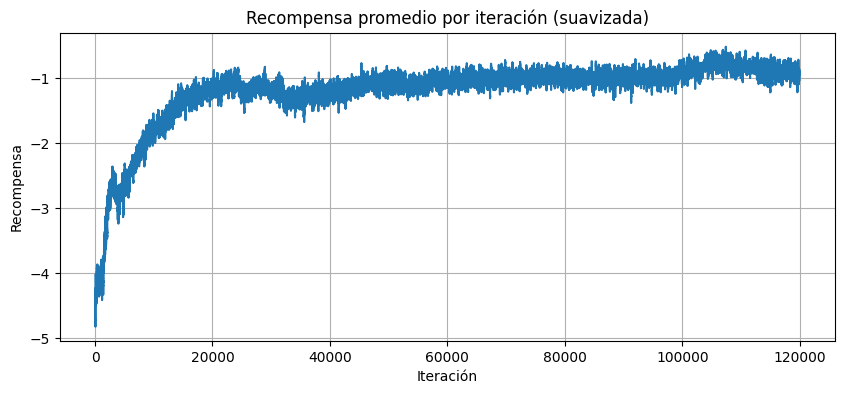

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def plot_rewards(reward_history, smooth=50):
    rewards = np.array(reward_history)
    if smooth > 1:
        kernel = np.ones(smooth) / smooth
        rewards = np.convolve(rewards, kernel, mode="valid")

    plt.figure(figsize=(10, 4))
    plt.plot(rewards)
    plt.title("Recompensa promedio por iteración (suavizada)")
    plt.xlabel("Iteración")
    plt.ylabel("Recompensa")
    plt.grid(True)
    plt.show()
    
plot_rewards(reward_history)


## 🎥 8. Grabación y Visualización del Agente en Acción

Este bloque define y ejecuta la función `record_mario_video()` que permite **grabar un episodio completo del agente entrenado** jugando Super Mario Bros y guardar el resultado como un archivo `.mp4`.

---

### 🛠️ ¿Qué hace la función?

1. **Inicializa el entorno `SuperMarioBros-v1`** con el wrapper `JoypadSpace`.
2. **Captura de frames**:
   - En cada paso del juego, guarda la imagen de la pantalla actual (`env.screen.copy()`).
3. **Preprocesamiento de observaciones**:
   - Escala de grises + redimensionado a 84×84 + apilamiento de 4 frames, igual que durante el entrenamiento.
4. **Inferencia de acciones**:
   - El agente ejecuta una acción basada en su política entrenada.
5. **Acumulación de recompensa total**:
   - Se lleva el conteo de la recompensa obtenida en todo el episodio.
6. **Finalización**:
   - Se detiene si el entorno devuelve `done=True`.
   - Se guarda el video como `mario_v1_episode512.mp4` en `/kaggle/working`.

---

### 📍 Parámetros clave:

- `max_steps`: número máximo de pasos a grabar (por defecto 500).
- `fps`: cuadros por segundo del video (por defecto 30).
- `filename`: nombre del archivo de salida.

---

### ✅ Resultado:

- Se genera un archivo de video `.mp4` que muestra cómo el agente juega un episodio completo.
- También se imprime la recompensa total alcanzada por el agente en esa corrida.

```python
🎥 Video guardado en: /kaggle/working/mario_v1_episode512.mp4 | Recompensa total: 523.00


In [8]:
import imageio
import numpy as np
import tensorflow as tf
import gym
import gym_super_mario_bros
from gym_super_mario_bros.actions import SIMPLE_MOVEMENT
from nes_py.wrappers import JoypadSpace

def record_mario_video(agent, max_steps=500, fps=30, filename='mario_fixed512.mp4'):

    env = gym_super_mario_bros.make("SuperMarioBros-v1")  # SIN render_mode
    env = JoypadSpace(env, SIMPLE_MOVEMENT)

    obs = env.reset()
    dummy_time_step = train_env.reset()
    frames = []
    total_reward = 0

    for step in range(max_steps):
        try:
            frames.append(env.screen.copy())
        except:
            continue

        obs_proc = np.expand_dims(obs, axis=0).astype(np.uint8)
        obs_proc = tf.image.rgb_to_grayscale(obs_proc)
        obs_proc = tf.image.resize(obs_proc, (84, 84))
        obs_proc = tf.cast(obs_proc, tf.uint8)
        obs_proc = tf.stack([obs_proc] * 4, axis=1)

        time_step = dummy_time_step._replace(observation=obs_proc)
        action_step = agent.policy.action(time_step)
        action = int(action_step.action.numpy()[0])

        obs, reward, done, _ = env.step(action)
        total_reward += reward

        if done:
            break

    env.close()
    output_path = f"/kaggle/working/{filename}"
    imageio.mimsave(output_path, frames, fps=fps)
    print(f"🎥 Video guardado en: {output_path} | Recompensa total: {total_reward:.2f}")
    return output_path

# Grabar y Guardar el video
video_path = record_mario_video(agent, max_steps=1500, filename="mario_v1_episode512.mp4")




/usr/local/lib/python3.11/dist-packages/gym/envs/registration.py:505: UserWarning: WARN: The environment SuperMarioBros-v1 is out of date. You should consider upgrading to version `v3` with the environment ID `SuperMarioBros-v3`.
  logger.warn(


🎥 Video guardado en: /kaggle/working/mario_v1_episode512.mp4 | Recompensa total: 523.00
